In [1]:
#SYSTEM IMPORTS
import os, re, json, shutil, filecmp, random, itertools, warnings, pickle, math
from datetime import datetime
from itertools import combinations, product
from math import ceil
#DS IMPORTS
import numpy as np
import pandas as pd
#PLOTTING IMPORTS
import matplotlib.pyplot as plt
from matplotlib import cm
import seaborn as sns
try:
    plt.style.use('tableau-colorblind10')
except OSError:
    pass
sns.set_palette('colorblind')
#PERSONAL IMPORTS
from preprocessor import NumpyEncoder, DataPreprocessor
from g16parser import g16parser
from jsonprocessor import JSONProcessor
from prepper import prepper
from plots import plots_class
#ML IMPORTS


verbose=False
debug=False

/home/pbuser/anaconda3/envs/heme/lib/python3.12/site-packages/Bio/Application/__init__.py:39: BiopythonDeprecationWarning: The Bio.Application modules and modules relying on it have been deprecated.

Due to the on going maintenance burden of keeping command line application
wrappers up to date, we have decided to deprecate and eventually remove these
modules.

We instead now recommend building your command line and invoking it directly
with the subprocess module.
  warnings.warn(


In [2]:
parse_g16 = False
if parse_g16:
    g16_parser = g16parser()
    g16_parser.parse()

In [3]:
prep_json = False
if prep_json:
    json_processor = JSONProcessor()
    json_processor.process_files()

In [4]:
df_large = pd.read_csv("tables/HESD_unfiltered.csv")

In [5]:
#for column in df_large.columns:
#    print(column)

In [6]:
#df_large["natural_charges[0].natural_charge"]

In [7]:
#for column in df_large.columns:
#    print(column)

In [8]:
df = pd.read_csv("tables/HESD_unfiltered.csv")

preprocess_data = True
if preprocess_data:
    preprocessor = DataPreprocessor(df=df)
    if debug:
        df, subsets_dict, replacements, df1, df2, df2_5, df3, df4 = preprocessor.process()
    else:
        df, subsets_dict, replacements = preprocessor.process()

Filtered out 5 structures with suspicious iron-axial distances
Suspicious PDB IDs: ['1ac8', '1iyn', '2vnx', '4oq7']
Remaining structures: 1076
Processing comprehensive quantum chemistry data...
Created Fe coordination analysis table: 2890 entries
Created orbital analysis table: 2890 entries
Created charge transfer analysis table: 1800 entries
Created spin contamination analysis table: 2890 entries
Created specialized quantum chemistry analysis tables in: prior_analysis/qm_analysis_tables
Creating filtering system for allowed PDB-ID/charge/multiplicity combinations...
Excluded 0 samples with invalid combinations or poor quality
Filtering report saved to: prior_analysis/filtering_report.json
Excluded 53 samples identified as quantum chemistry outliers
Excluded PDB IDs: ['1ash', '1f65', '1m20', '1n4g', '1xbn', '2spn', '2veb', '2vyw', '2vyz', '2wtg', '2xkh', '2z6s', '4g8w', '5eys', '5f0b', '5o18']
Excluding 295 samples with negative ligand field splitting energy
Removed 295 samples with ne

In [9]:
print(df["homo_lumo_gap"].mean())
print(df["homo_lumo_gap"].min())
print(df["homo_lumo_gap"].max())

0.10016429945054944
0.014839999999999992
0.11533000000000002


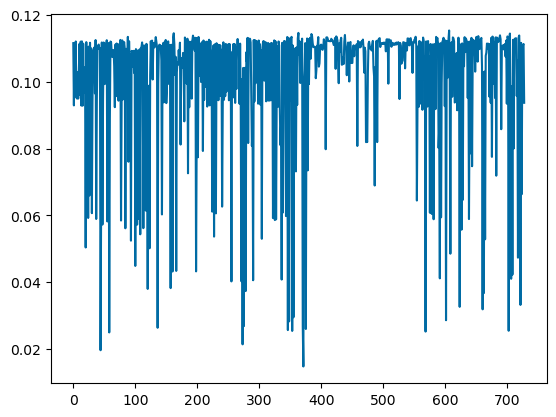

In [10]:
plt.plot(df["homo_lumo_gap"])

## Outlier Analysis

In [11]:
# Replace function definition with import and call to new class method
from preprocessor import DataAnalyzer

analyzer = DataAnalyzer()
df_large = analyzer.add_charge_multiplicity(df_large, file_col='file_name')

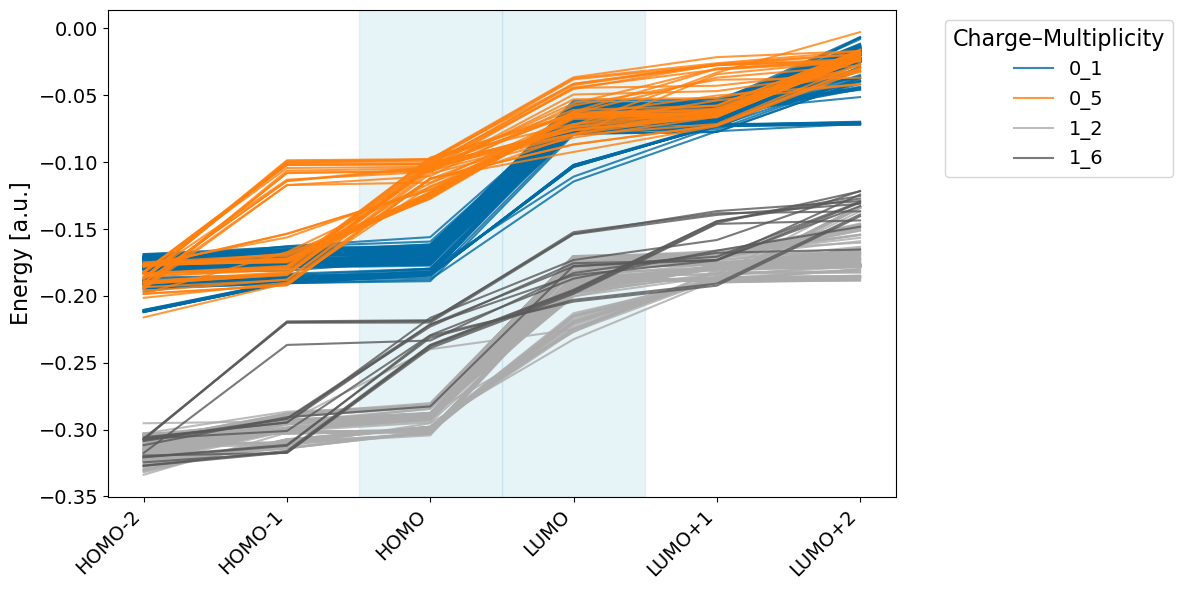

In [12]:
#from plots import plots_class
plots = plots_class()
plots.plot_x_random(df=df, mult_color=True, charge_color=True)

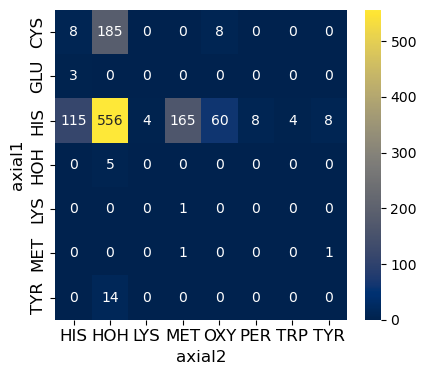

Heatmap saved as heatmap_axial1_axial2.png


In [13]:
p = plots_class()

# Converged models before top-5 axial ligand filtering (preprocessor step 4a)
df_converged_pre_axial = df_large[
    ~df_large['file_name'].astype(str).str.replace(r'\.[^.]*$', '', regex=True).str.endswith('re')
].copy()

# Generic categorical heatmap (compact size, larger fonts for LaTeX multi-figure use)
ct, ax = p.plot_categorical_categorical_heatmap(
    df=df_converged_pre_axial,
    col_x='axial1',
    col_y='axial2',
    decode_dicts=replacements,
    save=False,
    cell_size=0.55,
    min_figsize=(3.2, 2.8)
)

ax.set_xlabel('axial2', fontsize=14)
ax.set_ylabel('axial1', fontsize=14)
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')
ax.set_yticklabels(ax.get_yticklabels(), rotation=00, va='center')
for text in ax.texts:
    text.set_fontsize(11)

fig = ax.figure
fig.set_size_inches(3.6, 3.0)
fig.tight_layout(pad=0.2)
fig.savefig('plots/heatmap_axial1_axial2.png', dpi=300, bbox_inches='tight')
print('Heatmap saved as heatmap_axial1_axial2.png')

# Converged-only heatmap
#p.plot_convergence_heatmap(
#    df=df,
#    col_x='axial1',
#    col_y='axial2',
#    converged_col='converged',
#    converged_value=True,
#    decode_dicts=replacements,
#    save=True
#)

In [14]:
#plots.plot_x_random(df=df_large, mult_color=True, charge_color=True)

In [15]:
#plots.plot_x_random(df=df_large, axial_color=True, charge_color=True)

why do some very few of models show such significantly high energies in the HOMOs/LUMOs when looking at the unfiltered dataframe, but these samples are gone when looking at the filtered dataframe?

Probably because these models did not converge completely. 

In [16]:
# Replace function definitions with calls to new class methods
from preprocessor import DataAnalyzer

analyzer = DataAnalyzer()

# Use the methods from the DataAnalyzer class
groups = analyzer.split_df_by_charge_mult(df_large, file_col='file_name')
numeric_cols = [ col for col in df_large.columns if pd.api.types.is_numeric_dtype(df_large[col]) and any(substr in col.upper() for substr in ('HOMO', 'LUMO'))]

In [17]:
# 3) Choose your thresholds
n_std = 3           # e.g. 2 standard deviations
homo_threshold = -0.1

# 4) Run both filters on each subgroup using the DataAnalyzer class
outlier_results = {}
homo_results    = {}

for (c, m), subdf in groups.items():
    key = f"charge={c}, mult={m}"
    outlier_results[key] = analyzer.filter_significantly_high(subdf, numeric_cols, n_std=n_std)
    homo_results[key]    = analyzer.filter_homo_above(subdf, homo_threshold, col='homo[0]')

In [18]:
outlier_results["charge=0, mult=1"]

,file_name,warnings,job_info,total_energies[0],total_energies[1],homo[0],homo[1],homo[2],homo[3],homo[4],...,natural_electron_config[299].orbitals.3d,natural_electron_config[270].orbitals.3d,natural_electron_config[452].orbitals.3d,natural_electron_config[79].orbitals.4S,natural_electron_config[163].orbitals.3S,natural_electron_config[164].orbitals.3S,natural_electron_config[190].orbitals.3d,natural_electron_config[347].orbitals.3p,charge,multiplicity
1419,2v7j01.log,NaN,NaN,-3310.586537,-3310.586537,-0.23558,-0.23140,-0.22405,-0.21638,-0.20042,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1
1904,4kvk01.log,NaN,NaN,-3172.998786,-3172.998786,-0.23404,-0.22714,-0.22399,-0.21938,-0.20400,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1
2440,5mjc01.log,NaN,NaN,-3172.997381,-3172.997381,-0.23654,-0.23223,-0.21894,-0.21633,-0.20562,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1
2447,5n1t01.log,NaN,NaN,-3424.475493,-3424.475493,-0.24104,-0.22270,-0.21375,-0.21189,-0.20291,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1
2831,6vdq01.log,NaN,NaN,-3172.697374,-3172.697374,-0.23361,-0.22337,-0.21978,-0.21666,-0.20000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1


In [19]:
homo_results["charge=1, mult=6"]

,file_name,warnings,job_info,total_energies[0],total_energies[1],homo[0],homo[1],homo[2],homo[3],homo[4],...,natural_electron_config[299].orbitals.3d,natural_electron_config[270].orbitals.3d,natural_electron_config[452].orbitals.3d,natural_electron_config[79].orbitals.4S,natural_electron_config[163].orbitals.3S,natural_electron_config[164].orbitals.3S,natural_electron_config[190].orbitals.3d,natural_electron_config[347].orbitals.3p,charge,multiplicity


Inconclusive as of now

## Plots

In [20]:
p = plots_class()
#p.plot_publication_histogram(df=df, col="homo_lumo_gap", group_by_axial=True, replacements=replacements)

In [21]:
#p.plot_publication_histogram(df=df, col="homo_lumo_gap", group_by_charge=True, replacements=replacements)

In [22]:
if debug:
    cols = [c for c in df1.columns if 'natural_charges[0]'.lower() in c.lower()]
    print("natural_charges[0] in df1:", cols)
    cols = [c for c in df1.columns if 'iron_natural_charge'.lower() in c.lower()]
    print("iron_natural_charge in df1:", cols)

    cols = [c for c in df2.columns if 'natural_charges[0]'.lower() in c.lower()]
    print("natural_charges[0] in df2:", cols)
    cols = [c for c in df2.columns if 'iron_natural_charge'.lower() in c.lower()]
    print("iron_natural_charge in df2:", cols)
    cols = [c for c in df2_5.columns if 'iron_natural_charge'.lower() in c.lower()]
    print("iron_natural_charge in df2_5:", cols)

    cols = [c for c in df3.columns if 'natural_charges[0]'.lower() in c.lower()]
    print("natural_charges[0] in df3:", cols)
    cols = [c for c in df3.columns if 'iron_natural_charge'.lower() in c.lower()]
    print("iron_natural_charge in df3:", cols)

    cols = [c for c in df4.columns if 'iron'.lower() in c.lower()]
    print("iron in df4:", cols)

In [23]:
if verbose:
    for column in df.columns:
        print(column)

In [24]:
#verbose=True
if verbose: print(df.columns)
if verbose: df.tail()
if verbose: df["charge"].unique()
if verbose: df["multiplicity"].unique()

In [25]:
from plots import plots_class
plots = plots_class()

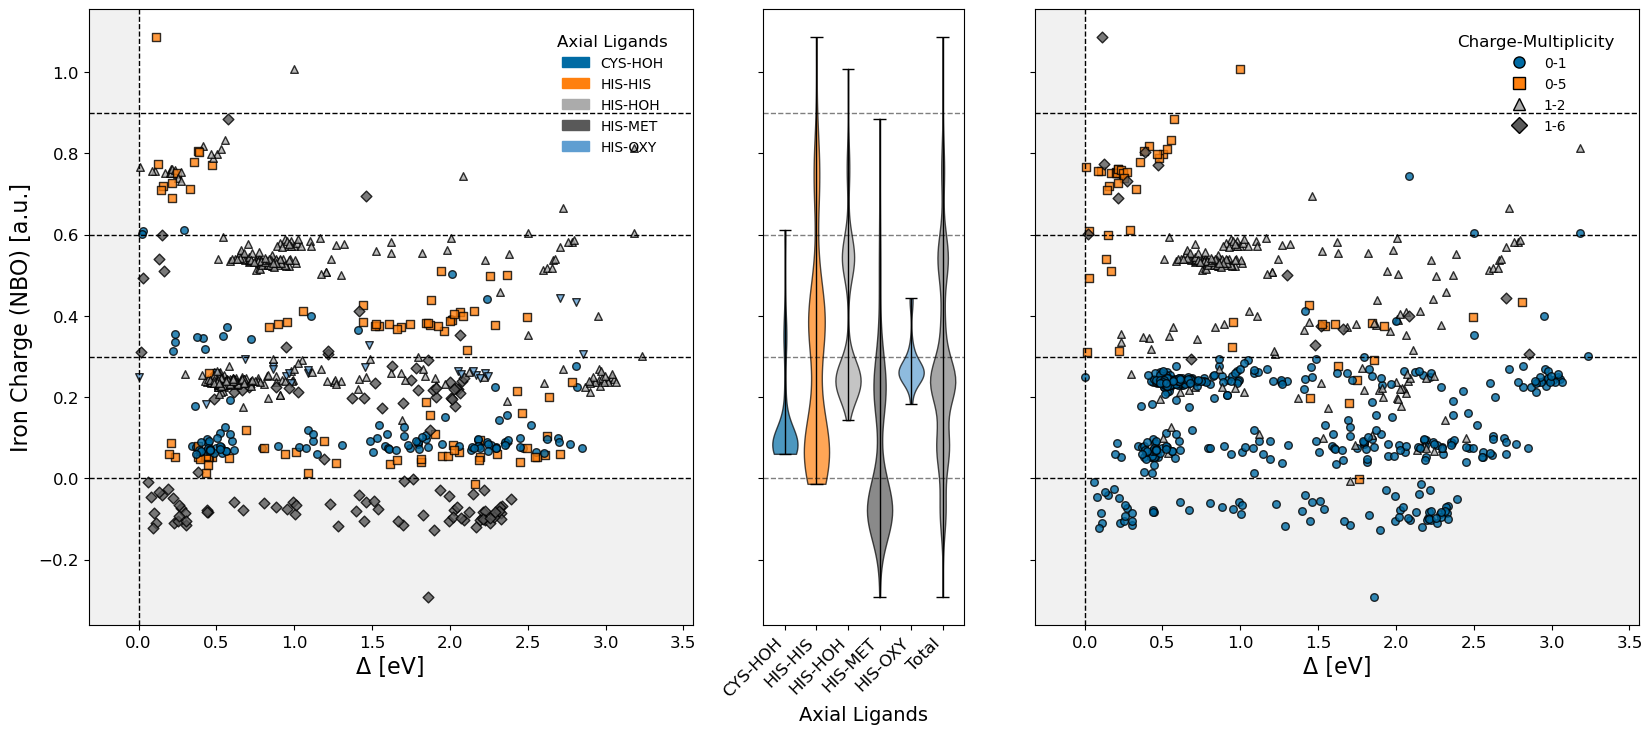

In [26]:
plots.plot_dual_lft_scatter_with_violin(
                                        df1=df, df2=df, x_col='lft_energy_delta', y_col='iron_natural_charge',
                                        color_by_left='axial',  # Color scheme for left plot
                                        color_by_right='charge_multiplicity',  # Color scheme for right plot
                                        color_by_violin='axial',  # Color scheme for violin plot
                                        save=True, save_dir='.', palette=None, figsize=(20, 8), marker_size=30,
                                        draw_dividers=True, light_lines=False, number_quadrants=False, violin_alpha=0.7,
                                        violin_width=0.8, color_grading=False, gray_background_condition=None, titles=None,
                                        convert_to_ev=True  # Convert from Hartree to eV
                                        )

Combined HOMO-LUMO plot saved as homo-lumo-gap_histogram.png


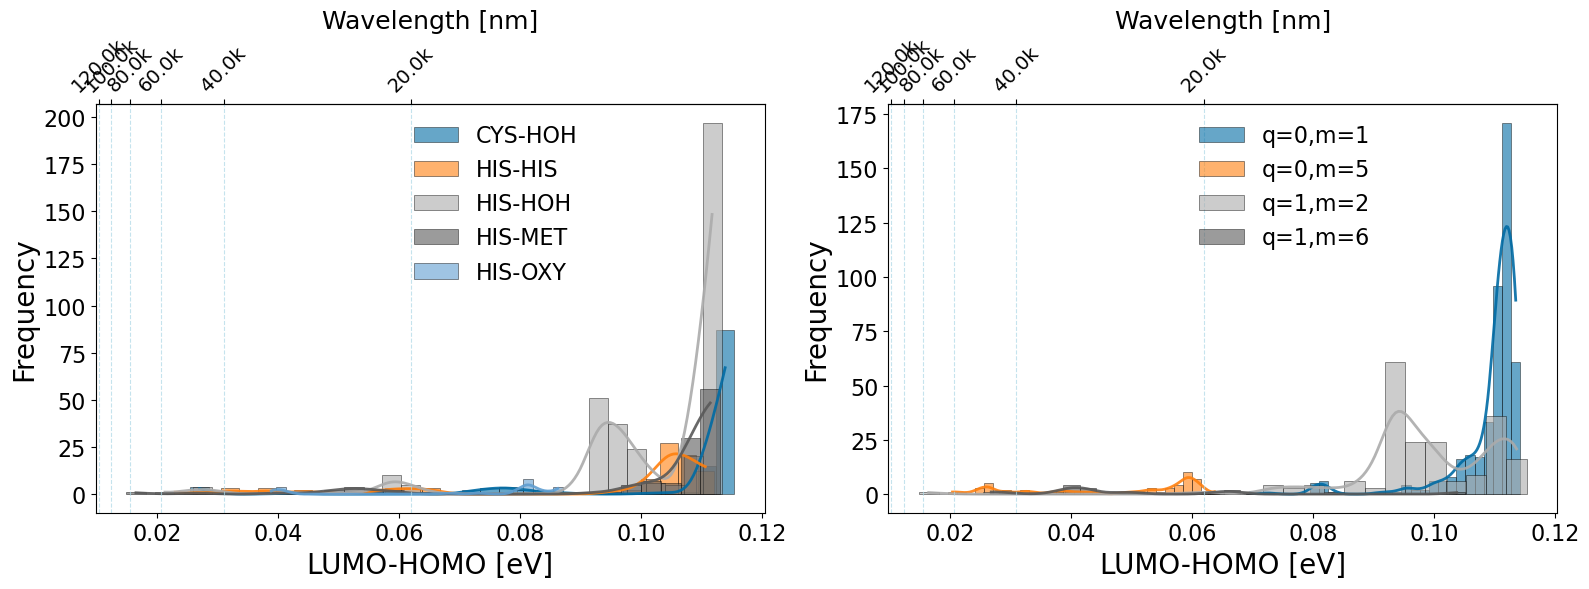

In [27]:
plots.plot_combined_homo_lumo_gap_histogram(df=df, column='homo_lumo_gap', bins=30, 
                                                save=True, save_dir='plots', opacity=0.6, 
                                                figsize=(16, 6))

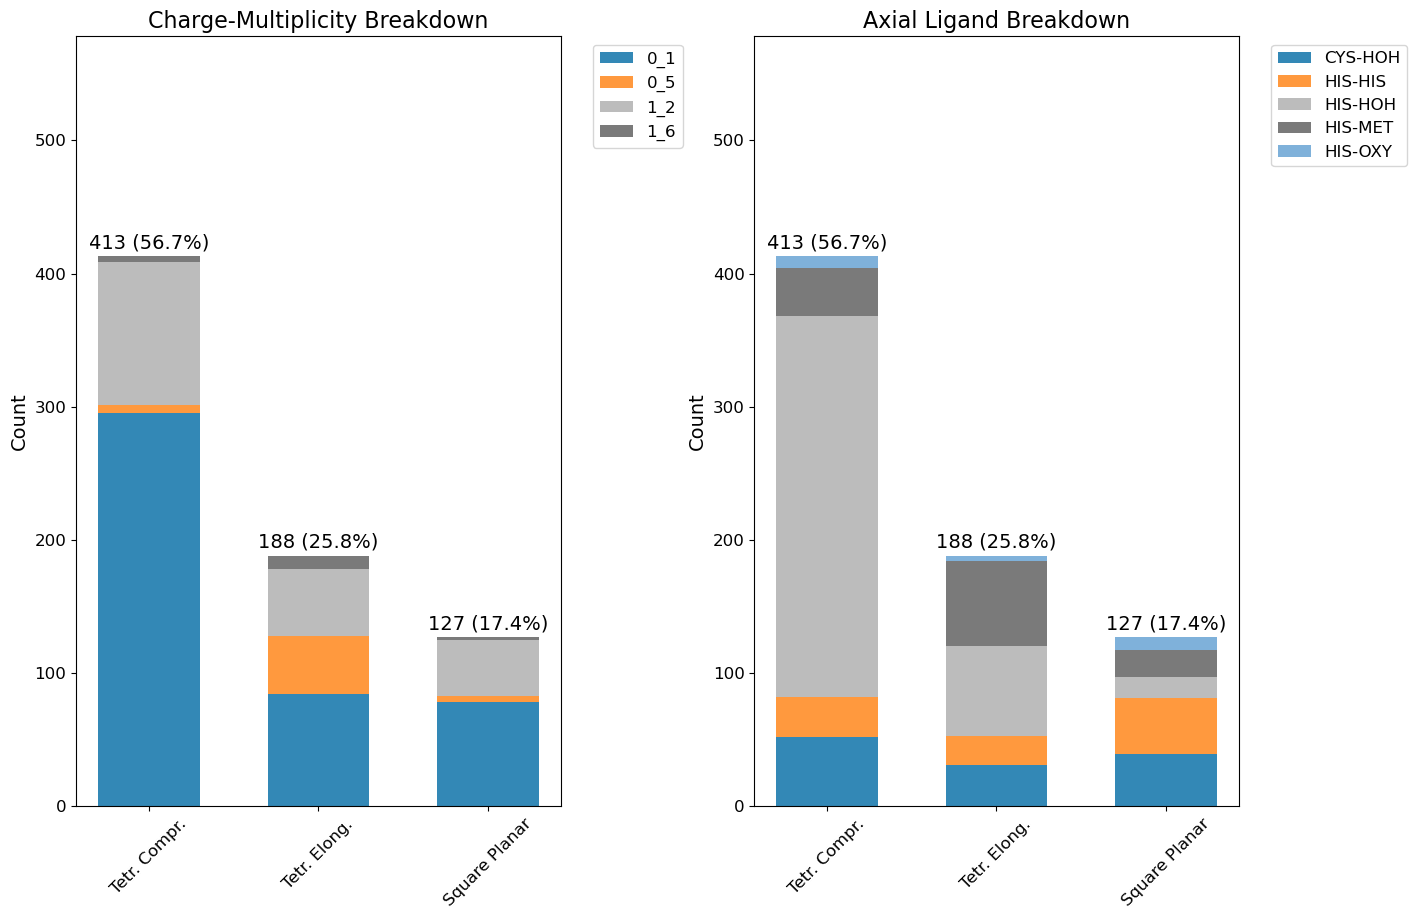

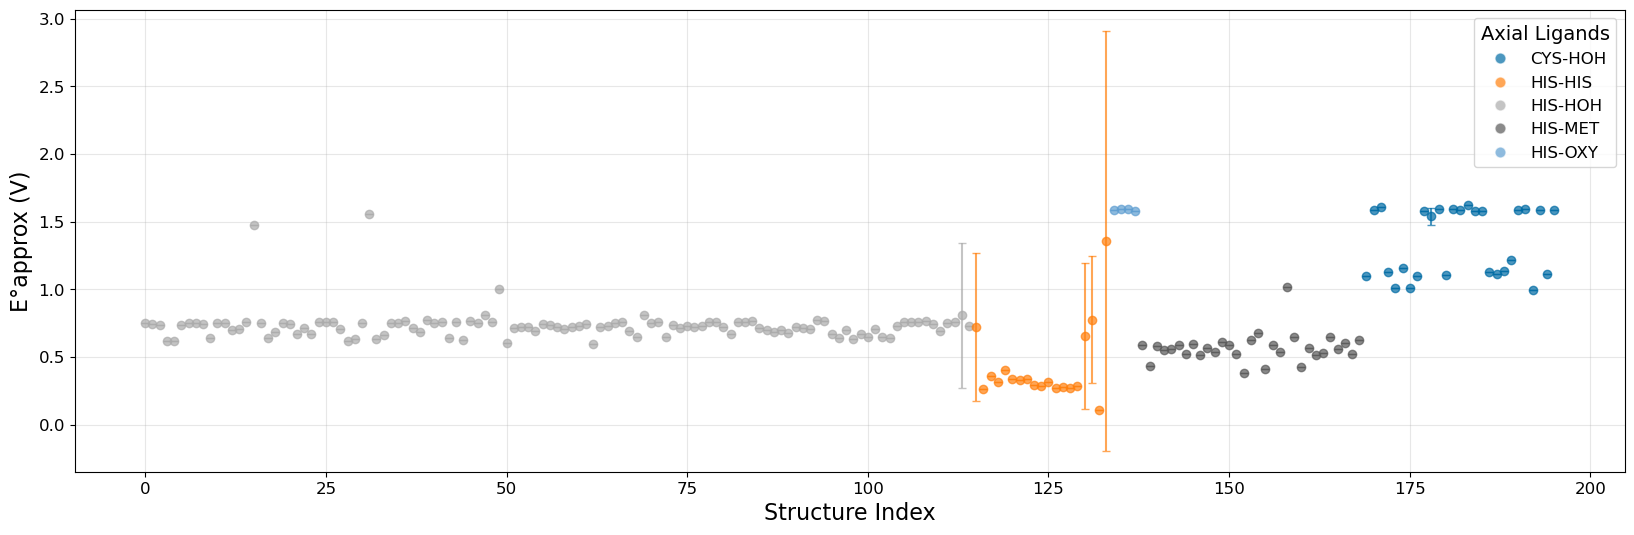

(    structure_id  E°approx (V)  std_dev (V)  num_red_ox_pairs  \
 0           1a2f      0.752429     0.000000                 1   
 1           1a6k      0.745663     0.000000                 1   
 2           1aa4      0.737488     0.000000                 1   
 3           1aej      0.617313     0.000000                 1   
 4           1aek      0.617313     0.000000                 1   
 ..           ...           ...          ...               ...   
 192         6u97      0.623739     0.000000                 1   
 193         6vdq      0.111342     0.000000                 1   
 194         6vxv      1.588210     0.000000                 1   
 195         6vz6      1.359525     1.550268                 2   
 196         6y2y      0.727261     0.000000                 1   
 
      num_reduced_states  num_oxidized_states  \
 0                     1                    1   
 1                     1                    1   
 2                     1                    1   
 3        

In [28]:
# Execute new plotting functions: plot_iron_d_orbital_energy_differences and plot_reduction_potentials_comprehensive
from plots import plots_class
plots = plots_class()
# Plot iron d-orbital energy differences using the new preprocessed data
plots.plot_iron_d_orbital_energy_differences(
    df=df, 
    save_dir='plots',
    figsize=(15, 10), 
    decode_dicts=replacements
)
# Plot reduction potentials comprehensive analysis
plots.plot_reduction_potentials_comprehensive(
    save_dir='plots', 
    figsize=(20, 12), 
    decode_dicts=replacements
    )

In [29]:
df["axial1"].unique()

array(['HIS', 'CYS'], dtype=object)

In [30]:
df["axial2"].unique()

array(['HOH', 'HIS', 'MET', 'OXY'], dtype=object)

In [31]:
# Print 3 example PDB-IDs per axial ligand combination
print("=" * 60)
print("Example PDB-IDs per Axial Ligand Combination")
print("=" * 60)

# Create axial combination column
df['axial_combo'] = df['axial1'] + '-' + df['axial2']

# Group by axial combination and get 3 examples per group
for combo in sorted(df['axial_combo'].unique()):
    combo_df = df[df['axial_combo'] == combo]
    pdb_ids = combo_df['file_name'].str[:4].unique()[:3]
    count = len(df[df['axial_combo'] == combo])
    
    print(f"\n{combo:>10s} ({count:3d} structures):")
    for i, pdb_id in enumerate(pdb_ids, 1):
        print(f"  {i}. {pdb_id}")

print("\n" + "=" * 60)

Example PDB-IDs per Axial Ligand Combination

   CYS-HOH (122 structures):
  1. 1cpt
  2. 1gjm
  3. 1lgf

   HIS-HIS ( 94 structures):
  1. 1aom
  2. 1cxy
  3. 1cyo

   HIS-HOH (369 structures):
  1. 1a2f
  2. 1a6k
  3. 1aa4

   HIS-MET (120 structures):
  1. 1c52
  2. 1c75
  3. 1cc5

   HIS-OXY ( 23 structures):
  1. 1dp6
  2. 1ltw
  3. 2gdm



  q=0, m=1: 457 structures
  q=0, m=5: 55 structures
  q=1, m=2: 200 structures
  q=1, m=6: 16 structures


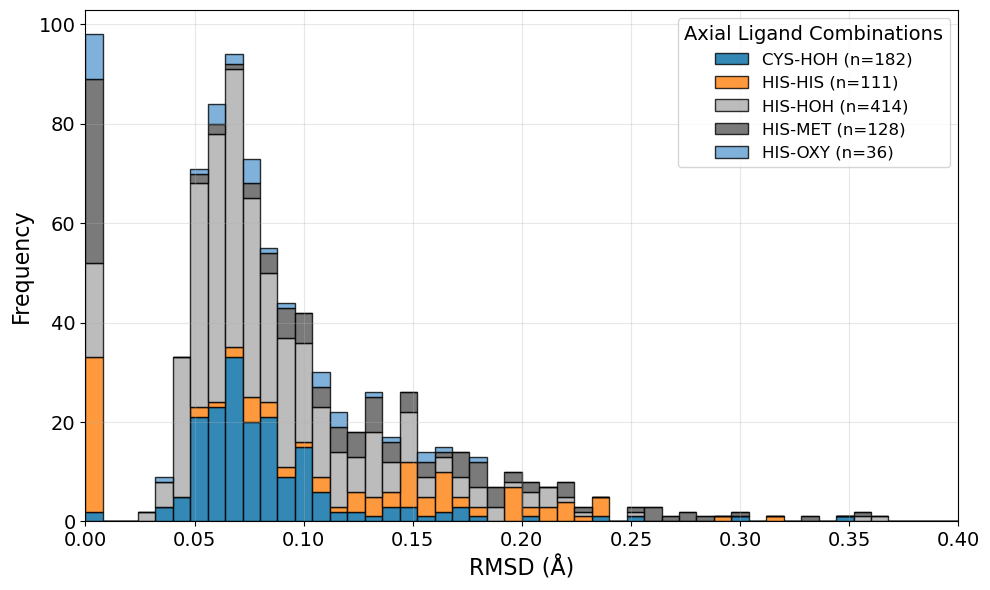

create_distance_difference_histogram called


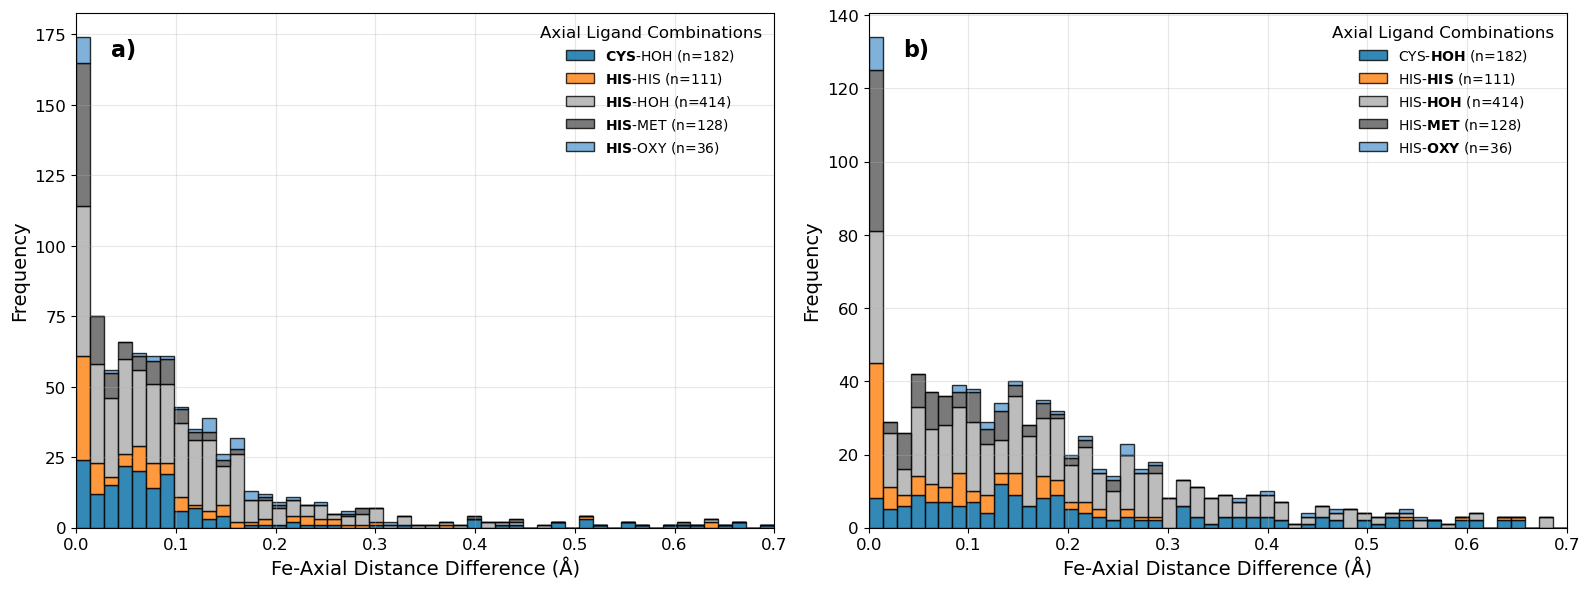

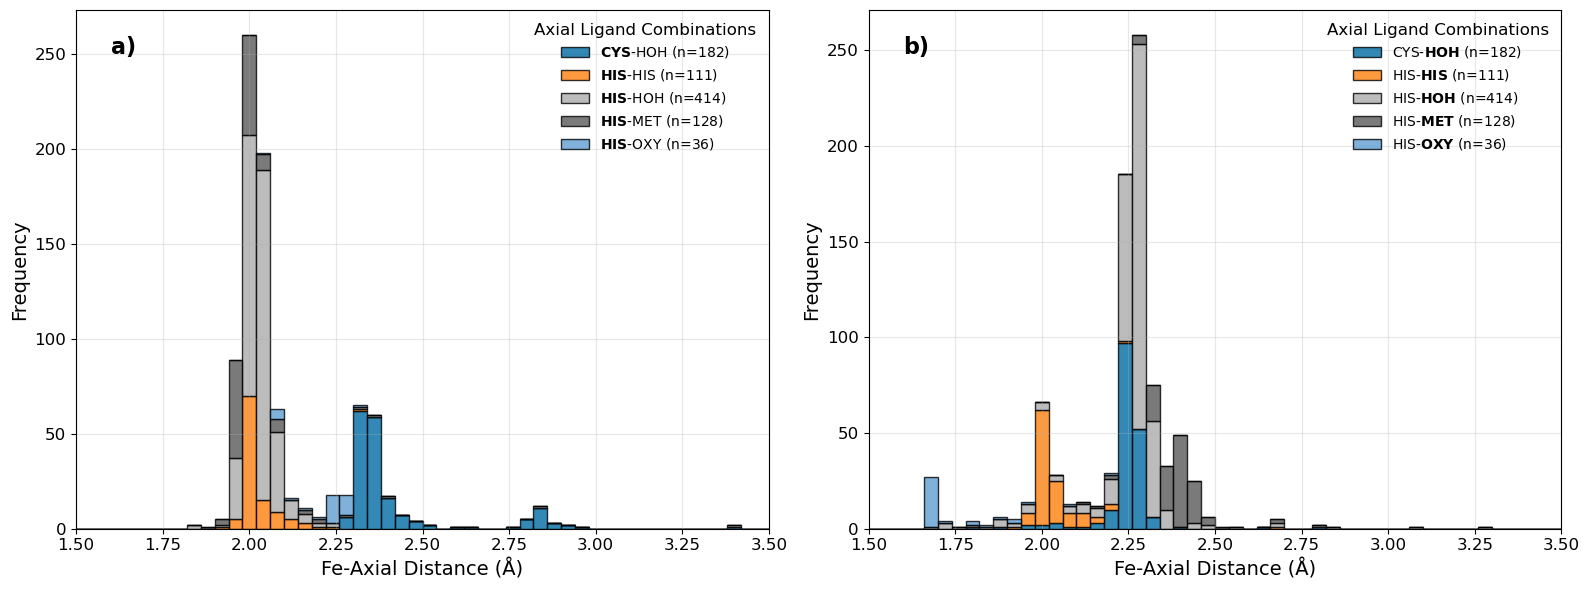

Distortion analysis moved to plots.py - use plots.plots_class().create_distortion_modes_histogram()


In [32]:
from calculate_rmsd import RMSDAnalyzer
rmsd_analyzer = RMSDAnalyzer()

charge_mult_data = df[['file_name', 'charge', 'multiplicity']].copy()
charge_mult_data['PDB_ID'] = charge_mult_data['file_name'].str[:4]
charge_mult_data = charge_mult_data[['PDB_ID', 'charge', 'multiplicity']].drop_duplicates()
combo_counts = charge_mult_data.groupby(['charge', 'multiplicity']).size()
for (charge, mult), count in combo_counts.items():
    print(f"  q={charge}, m={mult}: {count} structures")

analysis_results = rmsd_analyzer.run_all_analyses(
    rmsd=True,           # Calculate RMSD between PDB and XYZ structures  
    axial=True,          # Analyze iron-axial ligand distance differences
    iron_plane=True,     # Analyze iron displacement from heme plane with charge-mult breakdown
    absolute_iron_plane=True, # Analyze absolute iron displacement from heme plane with charge-mult breakdown
    distortion=True,    # Skip distortion analysis (not implemented yet)
    charge_mult_data=charge_mult_data  # Pass charge-multiplicity data for enhanced plotting
)

if 'rmsd' in analysis_results and not analysis_results['rmsd'].empty:
    rmsd_df = analysis_results['rmsd']

if 'axial_distances' in analysis_results and not analysis_results['axial_distances'].empty:
    axial_df = analysis_results['axial_distances']

if 'iron_plane_distances' in analysis_results and not analysis_results['iron_plane_distances'].empty:
    plane_df = analysis_results['iron_plane_distances']

## Create LaTeX tables

In [33]:
# Import the new simplified table creation functions
from create_latex_table import (
    create_total_energy_comprehensive_table, 
    create_lft_energy_base_statistical_table,
    create_lft_energy_baseline_normalized_table
)

print("Creating LaTeX tables using the new simplified system...")

# Create the requested tables:
# 1. Total electronic energy table with min, max, mean and std (comprehensive)
print("Creating total energy comprehensive table...")
create_total_energy_comprehensive_table(df)

# 2. LFT energy delta table with only mean and std (base statistical) 
print("Creating LFT energy delta base statistical table (no baseline normalization)...")
create_lft_energy_base_statistical_table(df)

# 3. LFT energy delta table with baseline normalization (charge_0_mult_1)
print("Creating LFT energy delta baseline normalized table...")
create_lft_energy_baseline_normalized_table(df)

print("Table creation complete!")
print("Generated files:")
print("- tables/total_energies_0__comprehensive_latex_table.txt")
print("- tables/lft_energy_delta_base_statistical_latex_table.txt")
print("- tables/lft_energy_delta_base_statistical_latex_table.txt (baseline normalized)")

Creating LaTeX tables using the new simplified system...
Creating total energy comprehensive table...
Creating LFT energy delta base statistical table (no baseline normalization)...
Creating LFT energy delta baseline normalized table...
Table creation complete!
Generated files:
- tables/total_energies_0__comprehensive_latex_table.txt
- tables/lft_energy_delta_base_statistical_latex_table.txt
- tables/lft_energy_delta_base_statistical_latex_table.txt (baseline normalized)


## Quantum Chemistry Analysis Plots

In [34]:
# Execute quantum chemistry analysis plotting for specialized tables
print("Generating exploratory plots for quantum chemistry analysis tables...")

# Import and run the quantum chemistry analysis plotter
from plot_qm_analysis import QMAnalysisPlotter

# Initialize the plotter with the specialized QM analysis tables
qm_plotter = QMAnalysisPlotter()

# Generate all exploratory plots
#qm_plotter.plot_all()

print("Quantum chemistry analysis plots completed!")

Generating exploratory plots for quantum chemistry analysis tables...
Loaded charge_transfer_analysis: 1800 rows, 9 columns
Loaded orbital_analysis: 2890 rows, 15 columns
Loaded spin_contamination_analysis: 2890 rows, 13 columns
Loaded fe_coordination_analysis: 2890 rows, 11 columns
Loaded processed_output.csv with columns: ['file_name', 'axial1', 'axial2', 'charge', 'multiplicity'] (728 rows)
Final auxiliary data shape: (728, 5)
Final auxiliary data columns: ['file_name', 'axial1', 'axial2', 'charge', 'multiplicity']
Charge/multiplicity coverage: 728/728 files
Axial ligand coverage: 728/728 files
Quantum chemistry analysis plots completed!


## Porphyrin Distortion Modes Analysis

In [35]:
# 2. Count structures with iron-porphyrin plane distance < 0.05 Å
print("\n2. Iron-Porphyrin Plane Distance Analysis")
print("-" * 50)

# Load iron-plane distance data from multiple possible sources
iron_plane_files = [
    "tables/iron_plane_distances_plots.csv",
    "tables/iron_plane_distances.csv"
]

plane_data_found = False

for filename in iron_plane_files:
    try:
        plane_data = pd.read_csv(filename)
        plane_data_found = True
        print(f"Loaded iron-plane data from: {filename}")
        print(f"Total structures analyzed for iron-plane distance: {len(plane_data)}")
        
        # Check available columns for distance data
        distance_cols = [col for col in plane_data.columns if 'distance' in col.lower() and 'plane' in col.lower()]
        if not distance_cols:
            # Try alternative column patterns
            distance_cols = [col for col in plane_data.columns if any(keyword in col.lower() for keyword in ['xyz_iron_plane', 'pdb_iron_plane'])]
        
        if distance_cols:
            print(f"Available distance columns: {distance_cols}")
            
            # Use the first available distance column (preferably XYZ optimized)
            distance_col = None
            for preferred_col in ['XYZ_Iron_Plane_Distance', 'xyz_iron_plane_distance', 'Plane_Distance']:
                if preferred_col in plane_data.columns:
                    distance_col = preferred_col
                    break
            
            if not distance_col:
                distance_col = distance_cols[0]
            
            print(f"Using distance column: {distance_col}")
            
            # Filter valid distances
            valid_distances = plane_data[distance_col].dropna()
            
            # Count structures with distance < 0.05 Å
            close_to_plane = valid_distances[valid_distances < 0.05]
            
            print(f"Structures with iron-plane distance < 0.05 Å: {len(close_to_plane)} ({100*len(close_to_plane)/len(valid_distances):.1f}%)")
            print(f"Mean iron-plane distance: {valid_distances.mean():.4f} ± {valid_distances.std():.4f} Å") 
            print(f"Median iron-plane distance: {valid_distances.median():.4f} Å")
            print(f"Distance range: [{valid_distances.min():.4f}, {valid_distances.max():.4f}] Å")
            
            # Show structures closest to plane
            if len(close_to_plane) > 0 and 'PDB_ID' in plane_data.columns:
                print(f"\nTop 10 most planar structures (closest to plane):")
                plane_data_sorted = plane_data.loc[valid_distances.index].copy()
                plane_data_sorted['Distance'] = valid_distances
                top_planar = plane_data_sorted.nsmallest(10, 'Distance')
                for i, (idx, row) in enumerate(top_planar.iterrows(), 1):
                    pdb_id = row.get('PDB_ID', f'Structure_{idx}')
                    print(f"  {i:2d}. {pdb_id}: {row['Distance']:.6f} Å")
            
        else:
            print("No suitable distance columns found in the data!")
            print(f"Available columns: {list(plane_data.columns)}")
        
        break  # Successfully processed, exit loop
        
    except FileNotFoundError:
        continue  # Try next file
    except Exception as e:
        print(f"Error loading {filename}: {e}")
        continue

if not plane_data_found:
    print(f"Iron-plane distance data files not found. Tried: {iron_plane_files}")
    print("Run the iron-plane analysis first to generate the data.")

print("\n" + "=" * 80)


2. Iron-Porphyrin Plane Distance Analysis
--------------------------------------------------
Loaded iron-plane data from: tables/iron_plane_distances_plots.csv
Total structures analyzed for iron-plane distance: 450
Available distance columns: ['PDB_Iron_Plane_Distance', 'XYZ_Iron_Plane_Distance', 'Plane_Distance_Difference']
Using distance column: XYZ_Iron_Plane_Distance
Structures with iron-plane distance < 0.05 Å: 220 (48.9%)
Mean iron-plane distance: 0.0702 ± 0.0655 Å
Median iron-plane distance: 0.0506 Å
Distance range: [0.0002, 0.4709] Å

Top 10 most planar structures (closest to plane):
   1. 1ls9: 0.000186 Å
   2. 3x33: 0.000273 Å
   3. 1m2m: 0.000346 Å
   4. 1cc5: 0.000383 Å
   5. 1ltw: 0.000714 Å
   6. 1u9u: 0.000729 Å
   7. 6ro8: 0.000844 Å
   8. 5mjc: 0.000951 Å
   9. 1ctj: 0.001090 Å
  10. 6wzc: 0.001182 Å



In [36]:
# Calculate and print statistics for structures with high-quality convergence
print("=" * 80)
print("STRUCTURE QUALITY STATISTICS")
print("=" * 80)

# 1. Count structures with RMSD < 0.05 Å
print("\n1. RMSD Analysis (PDB vs Optimized Structures)")
print("-" * 50)

# Load RMSD data
import pandas as pd
try:
    rmsd_data = pd.read_csv("tables/rmsd_results.csv")
    print(f"Total structures analyzed for RMSD: {len(rmsd_data)}")
    
    # Count structures with RMSD < 0.05 Å
    high_quality_rmsd = rmsd_data[rmsd_data['RMSD'] < 0.05]
    
    print(f"Structures with RMSD < 0.05 Å: {len(high_quality_rmsd)} ({100*len(high_quality_rmsd)/len(rmsd_data):.1f}%)")
    print(f"Mean RMSD: {rmsd_data['RMSD'].mean():.4f} ± {rmsd_data['RMSD'].std():.4f} Å")
    print(f"Median RMSD: {rmsd_data['RMSD'].median():.4f} Å")
    print(f"RMSD range: [{rmsd_data['RMSD'].min():.4f}, {rmsd_data['RMSD'].max():.4f}] Å")
    
    # Show some high-quality structures
    if len(high_quality_rmsd) > 0:
        print(f"\nTop 10 highest quality structures (lowest RMSD):")
        top_quality = high_quality_rmsd.nsmallest(10, 'RMSD')
        for i, (idx, row) in enumerate(top_quality.iterrows(), 1):
            print(f"  {i:2d}. {row['PDB_ID']}: {row['RMSD']:.6f} Å")
    
except FileNotFoundError:
    print("RMSD results file not found: tables/rmsd_results.csv")
except Exception as e:
    print(f"Error loading RMSD data: {e}")

STRUCTURE QUALITY STATISTICS

1. RMSD Analysis (PDB vs Optimized Structures)
--------------------------------------------------
Total structures analyzed for RMSD: 875
Structures with RMSD < 0.05 Å: 162 (18.5%)
Mean RMSD: 0.0923 ± 0.0678 Å
Median RMSD: 0.0762 Å
RMSD range: [0.0000, 0.7494] Å

Top 10 highest quality structures (lowest RMSD):
   1. 6k9j: 0.000000 Å
   2. 5utb: 0.000000 Å
   3. 2vyw: 0.000001 Å
   4. 7kyr: 0.000001 Å
   5. 1csx: 0.000001 Å
   6. 6jt6: 0.000001 Å
   7. 2bk9: 0.000001 Å
   8. 1es1: 0.000001 Å
   9. 1ehb: 0.000001 Å
  10. 5ibi: 0.000001 Å


Generating porphyrin distortion modes histogram...
Found distortion data in preprocessed dataframe
Axial ligand coloring enabled with 5 combinations:
  CYS-HOH: 122 structures
  HIS-HIS: 94 structures
  HIS-HOH: 369 structures
  HIS-MET: 120 structures
  HIS-OXY: 23 structures

Ruffling Statistics:
n=728, mean=-0.056, std=0.425

Saddling Statistics:
n=728, mean=-0.207, std=0.369

Doming Statistics:
n=728, mean=-0.046, std=0.142

Overall Ruffling Statistics:
Min: -1.573 Å, Max: 1.332 Å
Mean: -0.056 ± 0.425 Å
Total measurements: 728

Overall Saddling Statistics:
Min: -1.138 Å, Max: 0.774 Å
Mean: -0.207 ± 0.369 Å
Total measurements: 728

Overall Doming Statistics:
Min: -0.538 Å, Max: 0.413 Å
Mean: -0.046 ± 0.142 Å
Total measurements: 728


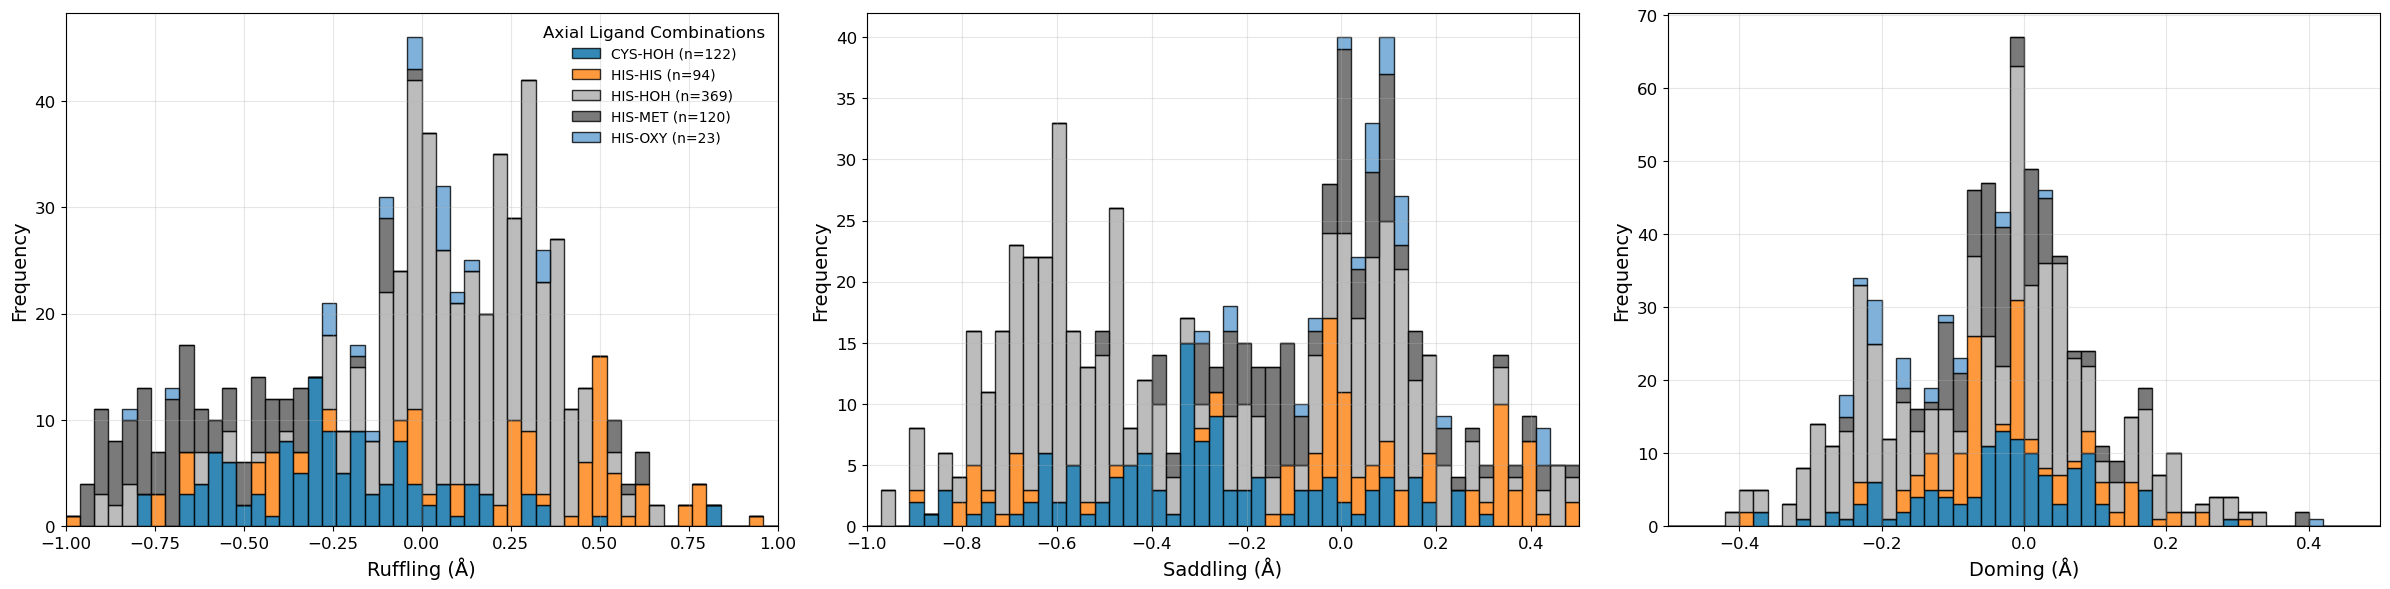

Distortion modes histogram saved to plots/porphyrin-distortions.png

Distortion Modes Statistics:
Ruffling:
  Mean: -0.056 ± 0.425 Å
  Range: [-1.573, 1.332] Å
  Structures: 728
Saddling:
  Mean: -0.207 ± 0.369 Å
  Range: [-1.138, 0.774] Å
  Structures: 728
Doming:
  Mean: -0.046 ± 0.142 Å
  Range: [-0.538, 0.413] Å
  Structures: 728
Distortion modes analysis completed!


In [37]:
# Plot porphyrin distortion modes using the new plots.py implementation
print("Generating porphyrin distortion modes histogram...")

# Create distortion modes plot using the plots_class
from plots import plots_class
plots = plots_class()

# Try to get distortion data from the preprocessed dataframe
# Check if distortion data is available in the current dataframe
distortion_cols = ['ruffling', 'saddling', 'doming']
distortion_available = all(col in df.columns for col in distortion_cols)

if distortion_available:
    print("Found distortion data in preprocessed dataframe")
    # Use the new plots.py method
    plots.create_distortion_modes_histogram(df, decode_dicts=replacements)
    
    # Display basic statistics for the distortion modes
    print("\nDistortion Modes Statistics:")
    for mode in distortion_cols:
        if mode in df.columns:
            values = df[mode].dropna()
            print(f"{mode.capitalize()}:")
            print(f"  Mean: {values.mean():.3f} ± {values.std():.3f} Å")
            print(f"  Range: [{values.min():.3f}, {values.max():.3f}] Å")
            print(f"  Structures: {len(values)}")
else:
    print("Distortion data not found in preprocessed dataframe")
    print("Available columns containing 'distort':")
    distort_cols = [col for col in df.columns if 'distort' in col.lower()]
    for col in distort_cols:
        print(f"  - {col}")
    
    # Try to load distortion data from external file
    try:
        import pandas as pd
        distortion_df = pd.read_csv("tables/pyDISH.csv")
        
        # Check if PDB_ID column exists or can be created
        if '# PDB' in distortion_df.columns:
            distortion_df['PDB_ID'] = distortion_df['# PDB']
        
        if distortion_cols[0] in distortion_df.columns and 'PDB_ID' in distortion_df.columns:
            print(f"Loaded external distortion data: {len(distortion_df)} structures")
            # Use the new plots.py method with external data
            plots.create_distortion_modes_histogram(distortion_df)
            
            # Display basic statistics for the distortion modes
            print("\nDistortion Modes Statistics (External Data):")
            for mode in distortion_cols:
                if mode in distortion_df.columns:
                    values = distortion_df[mode].dropna()
                    print(f"{mode.capitalize()}:")
                    print(f"  Mean: {values.mean():.3f} ± {values.std():.3f} Å")
                    print(f"  Range: [{values.min():.3f}, {values.max():.3f}] Å")
                    print(f"  Structures: {len(values)}")
        else:
            print("Required distortion columns not found in external file")
    except FileNotFoundError:
        print("External distortion data file not found: tables/pyDISH.csv")
    except Exception as e:
        print(f"Error loading external distortion data: {e}")

print("Distortion modes analysis completed!")

In [38]:

import pandas as pd

# Load the dataframe
df = pd.read_csv("tables/processed_output.csv")

# Get unique charge-multiplicity combinations
charge_mult_combos = df.groupby(['charge', 'multiplicity']).size().sort_values(ascending=False)

print("Unique charge-multiplicity combinations in your data:")
print("=" * 60)
for (charge, mult), count in charge_mult_combos.items():
    combo_str = f"{charge}-{mult}"
    print(f"  {combo_str:>6s}: {count:3d} structures")
print("=" * 60)
print(f"Total unique combinations: {len(charge_mult_combos)}")


Unique charge-multiplicity combinations in your data:
     0-1: 457 structures
     1-2: 200 structures
     0-5:  55 structures
     1-6:  16 structures
Total unique combinations: 4
